**U-net network for image segmentation** 

In [101]:
#!pip install imagecodecs
#!pip install --upgrade tifffile imagecodecs

In [102]:
import tensorflow as tf
import glob
import os
import numpy as np

**Encoder**

In [103]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    p = tf.keras.layers.MaxPool2D((2,2))(x)

    return x, p  

**Decoder**

In [104]:
def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(
        num_filters, (2, 2), strides=2, padding='same'
    )(inputs)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

**Defining the Unet model**

In [105]:
def unet_model(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    #s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(p3)
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(b1)

    #d1 = decoder_block(b1, s4, 512)
    d1 = decoder_block(b1, s3, 256)
    d2 = decoder_block(d1, s2, 128)
    d3 = decoder_block(d2, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d3)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_200 (Conv2D) │ (None, 512, 512,  │      1,792 │ input_layer_13[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_162      │ (None, 512, 512,  │          0 │ conv2d_200[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_201 (Conv2D) │ (None, 512, 512,  │     36,928 │ activation_162[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_163      │ (None, 512, 512,  │          0 │ conv2d_201[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_42    │ (None, 256, 256,  │          0 │ activation_163[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_202 (Conv2D) │ (None, 256, 256,  │     73,856 │ max_pooling2d_42… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_164      │ (None, 256, 256,  │          0 │ conv2d_202[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_203 (Conv2D) │ (None, 256, 256,  │    147,584 │ activation_164[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_165      │ (None, 256, 256,  │          0 │ conv2d_203[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 128, 128,  │          0 │ activation_165[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_204 (Conv2D) │ (None, 128, 128,  │    295,168 │ max_pooling2d_43… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_166      │ (None, 128, 128,  │          0 │ conv2d_204[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_205 (Conv2D) │ (None, 128, 128,  │    590,080 │ activation_166[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_167      │ (None, 128, 128,  │          0 │ conv2d_205[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_44    │ (None, 64, 64,    │          0 │ activation_167[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_206 (Conv2D) │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_44

 Total params: 7,697,345 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
def unet_model2(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(p4)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(b1)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model2(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_215 (Conv2D) │ (None, 512, 512,  │      1,792 │ input_layer_14[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_174      │ (None, 512, 512,  │          0 │ conv2d_215[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_216 (Conv2D) │ (None, 512, 512,  │     36,928 │ activation_174[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_175      │ (None, 512, 512,  │          0 │ conv2d_216[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_45    │ (None, 256, 256,  │          0 │ activation_175[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_217 (Conv2D) │ (None, 256, 256,  │     73,856 │ max_pooling2d_45… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_176      │ (None, 256, 256,  │          0 │ conv2d_217[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_218 (Conv2D) │ (None, 256, 256,  │    147,584 │ activation_176[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_177      │ (None, 256, 256,  │          0 │ conv2d_218[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 128, 128,  │          0 │ activation_177[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_219 (Conv2D) │ (None, 128, 128,  │    295,168 │ max_pooling2d_46… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_178      │ (None, 128, 128,  │          0 │ conv2d_219[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_220 (Conv2D) │ (None, 128, 128,  │    590,080 │ activation_178[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_179      │ (None, 128, 128,  │          0 │ conv2d_220[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_47    │ (None, 64, 64,    │          0 │ activation_179[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_221 (Conv2D) │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_47

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

**data loading**

**Load paths**

In [107]:
import os
import glob

ROOT = "/kaggle/input/datasets/cedricniango"

IMAGE_DIR = os.path.join(ROOT, "dir-01-png")
MASK_DIR  = os.path.join(ROOT, "01-gt-seg-png")


def get_dataset_paths(image_dir, mask_dir):

    image_paths = sorted(glob.glob(os.path.join(image_dir, "t*.png")))

    mask_files = set(os.listdir(mask_dir))

    image_list = []
    mask_list = []

    for img_path in image_paths:

        name = os.path.basename(img_path)
        idx = ''.join(filter(str.isdigit, name))

        mask_name = f"man_seg{idx}.png"

        if mask_name in mask_files:
            image_list.append(img_path)
            mask_list.append(os.path.join(mask_dir, mask_name))

    print(f"Matched pairs: {len(image_list)}")

    return image_list, mask_list

**Image Preprocessing and mask** 

In [108]:
import imageio.v2 as imageio
#import tifffile as tiff
import tensorflow as tf
import numpy as np

IMG_SIZE = 512

def load_sample(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=1)

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.cast(mask > 0, tf.float32)

    return img, mask

**Data augmentation**

In [109]:
'''def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask'''

def augment(img, mask):

    # horizontal flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # vertical flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # 90° Rotation 
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # Brightness (image only)
    img = tf.image.random_brightness(img, max_delta=0.1)

    # Contrast (image only)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    # 
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.02)
    img = img + noise

    # Clipping
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

**RANDOM CROP**

In [110]:
def random_crop(img, mask, crop_size=256):
    #Concate image and mask for identically crop
    combined = tf.concat([img, mask], axis=-1)

    cropped = tf.image.random_crop(
        combined,
        size=[crop_size, crop_size, combined.shape[-1]]
    )

    img_crop = cropped[..., :img.shape[-1]]
    mask_crop = cropped[..., img.shape[-1]:]

    return img_crop, mask_crop

**Dataset creation**

In [111]:
def create_dataset(image_paths, mask_paths, batch_size=8, augment_data=True):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    dataset = dataset.map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    #Cropping
    dataset = dataset.map(
        lambda x, y : random_crop(x, y, 256),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_data:
        dataset = dataset.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.shuffle(100)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

**Usage**

In [112]:
ROOT = "DIC-C2DH-HeLa"
IMAGE_DIR = "/kaggle/input/datasets/cedricniango/dir-01-png"
MASK_DIR = "/kaggle/input/datasets/cedricniango/01-gt-seg-png"

IMAGE_DIR_valid = "/kaggle/input/datasets/cedricniango/dir-02-png"
MASK_DIR_valid = "/kaggle/input/datasets/cedricniango/02-gt-seg-png"

train_img, train_mask = get_dataset_paths(IMAGE_DIR, MASK_DIR)
valid_img, valid_mask = get_dataset_paths(IMAGE_DIR_valid, MASK_DIR_valid)

train_dataset = create_dataset(train_img, train_mask, batch_size=4, augment_data=True)
valid_dataset  = create_dataset(valid_img, valid_mask, batch_size=4, augment_data=False)

Matched pairs: 9
Matched pairs: 9


**VERIFICATION**

In [ ]:
import matplotlib.pyplot as plt

def show_sample(ds):
    for img, mask in ds.take(4):
        plt.figure(figsize=(10,3))

        plt.subplot(1,2,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap='gray')

        plt.subplot(1,2,2)
        plt.title("Mask")
        plt.imshow(mask[0,...,0], cmap='gray')

        plt.show()

show_sample(train_dataset)

**TRAINING AND LOSS FUNCTION**

*Loss function*

In [114]:
# Loss BCE (Binary cross-entropy): https://softwaremill.com/instance-segmentation-loss-functions/
# Loss Dice : https://www.tensorflow.org/api_docs/python/tf/keras/losses/Dice
def dice_loss(y_true, y_pred, epsi=1e-7):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    #epsi = 1e-7
    #dice loss = 1 - dice_score
    return 1 - (2 * tf.reduce_sum(y_true * y_pred)) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + epsi) #Intersection / Union


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * d_loss

**Compile model**

In [115]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [116]:
IMAGE_SIZE = 256
model = unet_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1), num_classes=1)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss=bce_dice_loss,
             metrics=["accuracy"]
             )

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=50,              # nb of epochs without improvement
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    #verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    mode='min',
    save_best_only=True,
    verbose=1
)

In [117]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=400,
    callbacks=[reduce_lr]
    #callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/400


2026-04-24 00:25:38.982503: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.48 = (f32[4,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,128,128]{3,2,1,0} %bitcast.8113, f32[128,128,3,3]{3,2,1,0} %bitcast.6693, f32[128]{0} %bitcast.8173), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_14_1/conv2d_237_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-24 00:25:39.029598: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.047349378s
Trying a

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5667 - loss: 0.6145

2026-04-24 00:26:15.537922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:15.746128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:16.274504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:16.541730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:18.630477: E external/local_xla/xla/stream_

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5603 - loss: 0.6066   

2026-04-24 00:26:34.335924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:34.567355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:35.571742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:35.880088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 00:26:42.463249: E external/local_xla/xla/stream_

3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 16s/step - accuracy: 0.5572 - loss: 0.6026 - val_accuracy: 0.6914 - val_loss: 0.5535 - learning_rate: 1.0000e-04
Epoch 2/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.5753 - loss: 0.5768 - val_accuracy: 0.6997 - val_loss: 0.5460 - learning_rate: 1.0000e-04
Epoch 3/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.6088 - loss: 0.5650 - val_accuracy: 0.6199 - val_loss: 0.5581 - learning_rate: 1.0000e-04
Epoch 4/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.5828 - loss: 0.5672 - val_accuracy: 0.6513 - val_loss: 0.5420 - learning_rate: 1.0000e-04
Epoch 5/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.5553 - loss: 0.5688 - val_accuracy: 0.6663 - val_loss: 0.5229 - learning_rate: 1.0000e-04
Epoch 6/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.6213 - loss: 0.5368 - val_accuracy: 0.7271 - val_loss: 0.4656 - learning_rate: 1.0000e-04
Epoch 7/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.5140 - loss: 0.576

In [124]:
# Save model
model.save("unet_model_400_rlr.keras")

**Plot training curves**

In [125]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

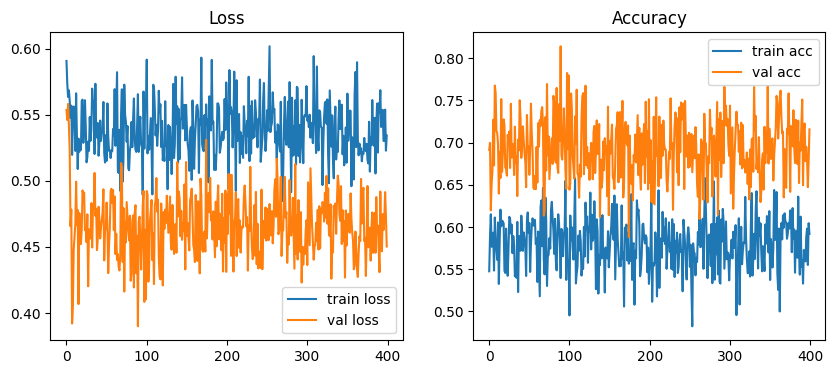

In [120]:
import matplotlib.pyplot as plt

def plot_training(history):

    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy (si disponible)
    if "accuracy" in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history["accuracy"], label="train acc")
        plt.plot(history.history["val_accuracy"], label="val acc")
        plt.title("Accuracy")
        plt.legend()

    plt.show()

plot_training(history)

**Save curves**

In [121]:
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

**INFERENCE**

In [3]:
def load_test_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)

    img = tf.image.resize(img, (512, 512))
    img = tf.cast(img, tf.float32) / 255.0

    return img

def create_test_dataset(image_paths, batch_size=4):

    dataset = tf.data.Dataset.from_tensor_slices(image_paths)

    dataset = dataset.map(
        lambda x: load_test_image(x),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


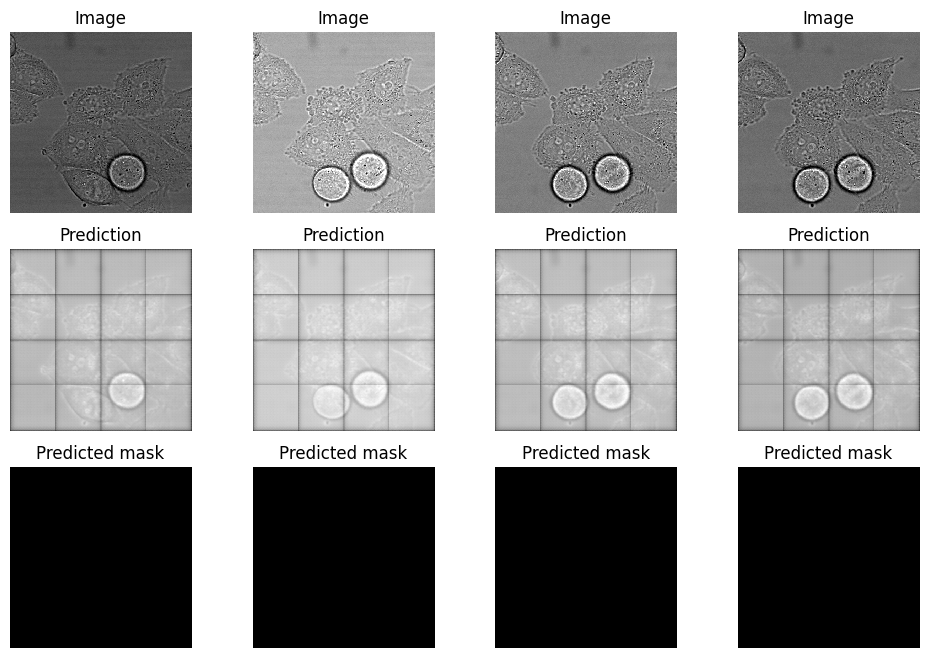

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


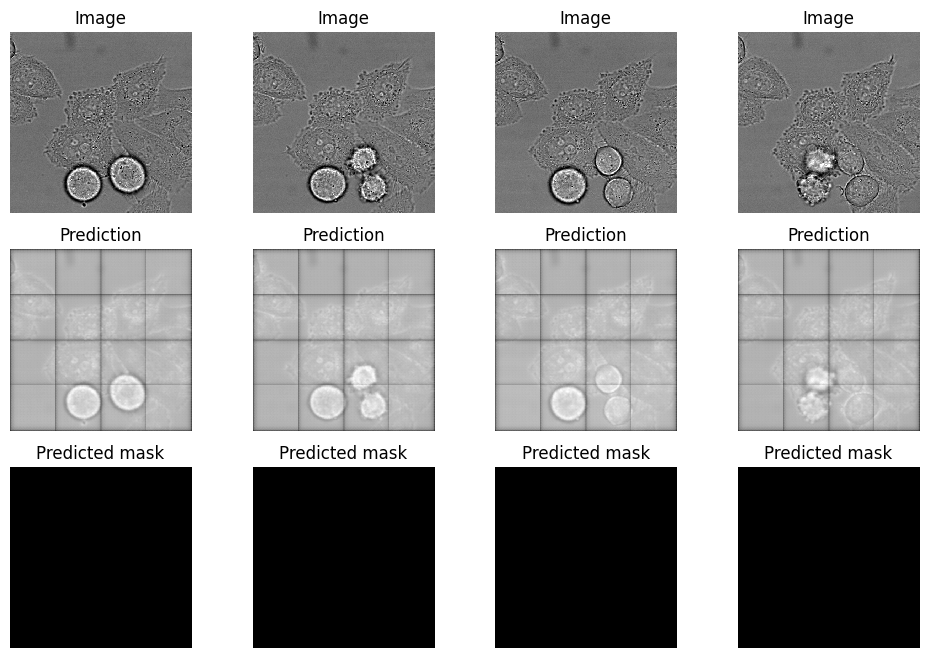

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


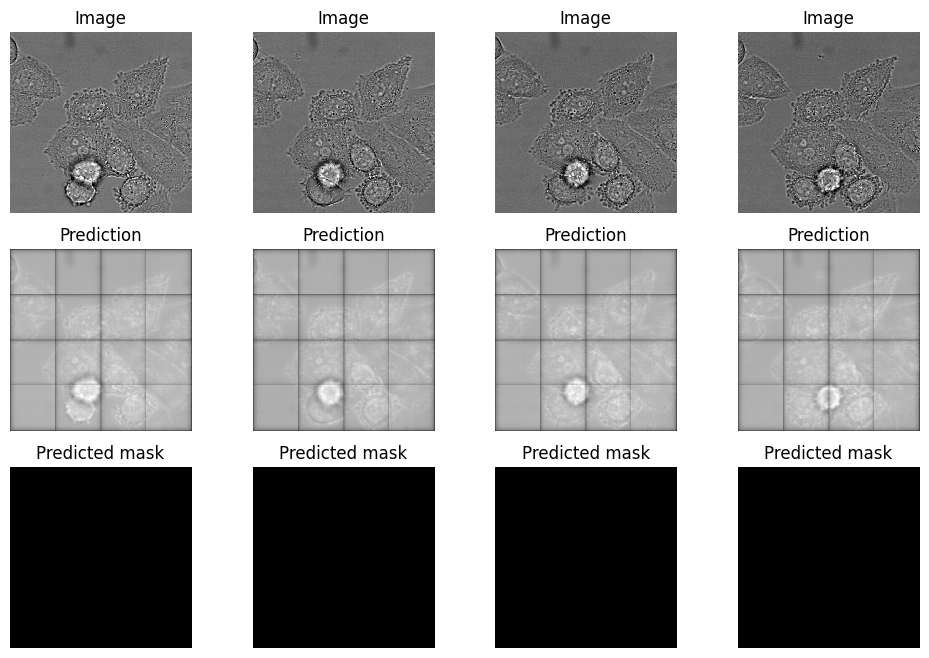

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


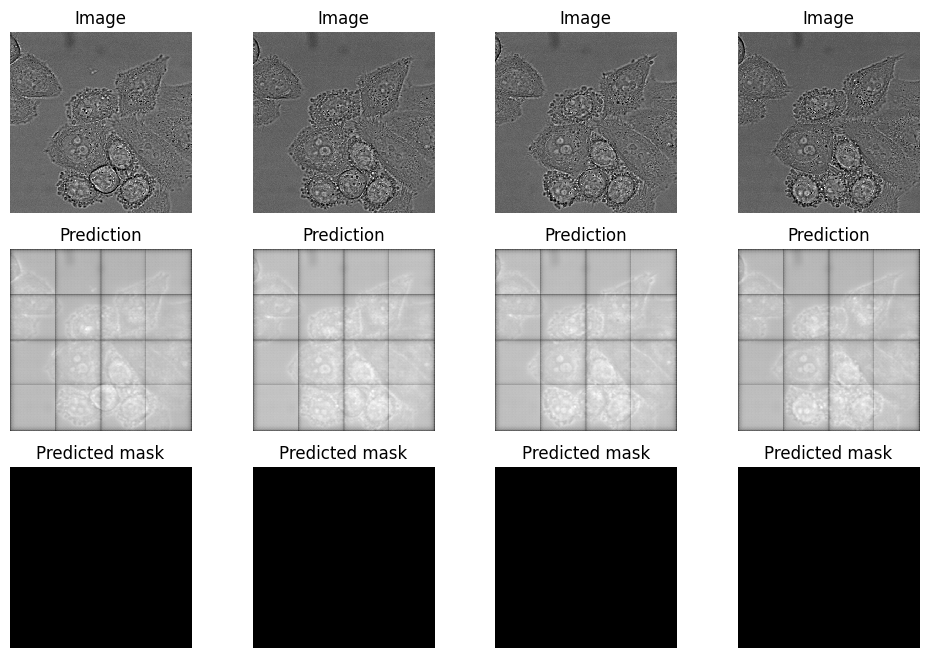

In [12]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob

#Load model
model = tf.keras.models.load_model(
                                  '/kaggle/input/models/cedricniango/unet-256x256/tensorflow2/default/1/unet_model_400_rlr_256x256.keras',
                                   compile=False)

# Test set
IMAGE_DIR_test = "/kaggle/input/datasets/cedricniango/dir-01-test-png"
test_img = sorted(glob.glob(os.path.join(IMAGE_DIR_test, '*.png')))
test_dataset = create_test_dataset(test_img, batch_size=4)

'''def show_predictions(model, dataset):

    for img, mask in dataset.take(1):

        pred = model.predict(img)

        plt.figure(figsize=(12,4))

        # Image
        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap="gray")

        # Ground truth
        plt.subplot(1,3,2)
        plt.title("Mask GT")
        plt.imshow(mask[0,...,0], cmap="gray")

        # Prediction
        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred[0,...,0] > 0.5, cmap="gray")

        plt.show()

show_predictions(model, test_dataset)'''
#preds = model.predict(test_dataset)
import numpy as np

def predict_with_overlap(model, imgs, patch_size=256, stride=128):

    batch_size, H, W, C = imgs.shape

    final_pred = np.zeros((batch_size, H, W, 1), dtype=np.float32)
    counter = np.zeros((batch_size, H, W, 1), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = imgs[:, y:y+patch_size, x:x+patch_size, :]
            final_pred[:, y:y+patch_size, x:x+patch_size, :] += model.predict(patch)
            counter[:, y:y+patch_size, x:x+patch_size, :] += 1

    final_pred /= counter

    return final_pred

def predict_with_split(model, imgs, IMG_SIZE = 256):
    ##predict on patches
    #print(f"SHAPE: {imgs.shape}") Input: 4 x 512 x 512 x 1
    preds11 = model.predict(imgs[:, :IMG_SIZE, :IMG_SIZE, :])
    preds12 = model.predict(imgs[:, :IMG_SIZE, IMG_SIZE:, :])
    preds21 = model.predict(imgs[:, IMG_SIZE:, :IMG_SIZE, :])
    preds22 = model.predict(imgs[:, IMG_SIZE:, IMG_SIZE:, :])
    #Concat differente tensors
    preds1 = tf.concat([preds11, preds12], axis=2)
    #print(f"preds1: {preds1.shape}")
    preds2 = tf.concat([preds21, preds22], axis=2)
    #print(f"preds2: {preds2.shape}")
    #Final image
    preds = tf.concat([preds1, preds2], axis=1)
    return preds

IMG_SIZE = 256
def show_predictions(dataset, model):

    for imgs in dataset.take(4):
        '''
        ##predict on patches
        #print(f"SHAPE: {imgs.shape}") Input: 4 x 512 x 512 x 1
        preds11 = model.predict(imgs[:, :IMG_SIZE, :IMG_SIZE, :])
        preds12 = model.predict(imgs[:, :IMG_SIZE, IMG_SIZE:, :])
        preds21 = model.predict(imgs[:, IMG_SIZE:, :IMG_SIZE, :])
        preds22 = model.predict(imgs[:, IMG_SIZE:, IMG_SIZE:, :])
        #Concat differente tensors
        preds1 = tf.concat([preds11, preds12], axis=2)
        #print(f"preds1: {preds1.shape}")
        preds2 = tf.concat([preds21, preds22], axis=2)
        #print(f"preds2: {preds2.shape}")
        #Final image
        preds = tf.concat([preds1, preds2], axis=1)'''
        #preds = predict_with_overlap(model, imgs)
        preds = predict_with_split(model, imgs)

        plt.figure(figsize=(12,8))

        for i in range(4):

            plt.subplot(3,4,i+1)
            plt.imshow(imgs[i], cmap='gray', interpolation='nearest')
            plt.title("Image")
            plt.axis("off")

            plt.subplot(3,4,i+5)
            plt.imshow(preds[i,...,0], cmap="gray", interpolation='nearest')
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Prediction")
            plt.axis("off")

            plt.subplot(3,4,i+9)
            plt.imshow(preds[i,...,0] > 0.5, cmap="gray", interpolation='nearest')
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Predicted mask")
            plt.axis("off")

        plt.show()
show_predictions(test_dataset, model)